Loading embeddings...
Building DataLoaders...
Building embedding matrices...
Initializing SS-BED model...
Training...
Epoch [1/8] Train Loss: 1.0929 Val Loss: 0.5809 Val Acc: 0.8610
Epoch [2/8] Train Loss: 0.8038 Val Loss: 0.6106 Val Acc: 0.8120
Epoch [3/8] Train Loss: 0.7650 Val Loss: 0.6421 Val Acc: 0.8365
Epoch [4/8] Train Loss: 0.6912 Val Loss: 0.5281 Val Acc: 0.8673
Epoch [5/8] Train Loss: 0.6532 Val Loss: 0.6196 Val Acc: 0.8636
Epoch [6/8] Train Loss: 0.6247 Val Loss: 0.5334 Val Acc: 0.8476
Epoch [7/8] Train Loss: 0.6082 Val Loss: 0.5928 Val Acc: 0.8580
Epoch [8/8] Train Loss: 0.5918 Val Loss: 0.5864 Val Acc: 0.8580
Final evaluation on test set...
Test Loss: 0.5520, Test Acc: 0.8545
Full Classification Report (including 'others'):
              precision    recall  f1-score   support

      others       0.94      0.90      0.92      4617
       happy       0.40      0.41      0.40       227
         sad       0.42      0.57      0.49       224
       angry       0.53      0.72   

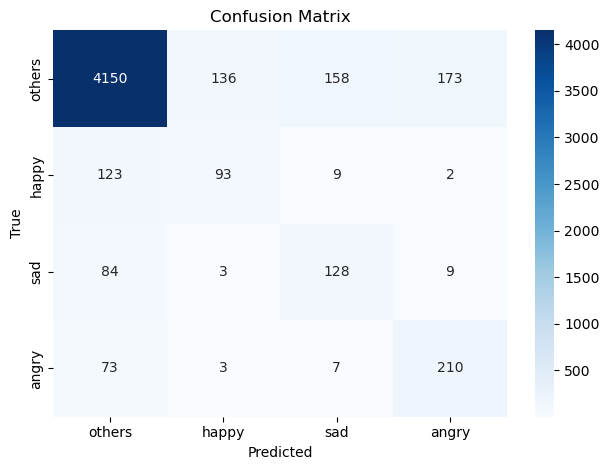

In [1]:
import torch
from torch import nn
from data import get_dataloaders
from embeddings import load_sswe_embeddings, load_glove_embeddings, build_embedding_matrices
from model import SSBedModel
from train import train_model, evaluate_model
from evaluate import evaluate_and_print
import random
import numpy as np
import torch

def main():

    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    # Hyperparameters
    batch_size = 128
    max_len = 30
    hidden_dim = 64
    num_layers = 2
    sswe_dim = 50
    glove_dim = 100
    num_classes = 4
    dropout = 0.25
    learning_rate = 0.005
    epochs = 8
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # File paths to your embedding text files
    sswe_path = "word_embeddings/sswe_embedding.txt"   # SSWE-u: 50D
    glove_path = "word_embeddings/glove.6B.100d.txt"   # GloVe: 100D

    print("Loading embeddings...")
    sswe_dict = load_sswe_embeddings(sswe_path)
    glove_dict = load_glove_embeddings(glove_path)

    print("Building DataLoaders...")
    # We pass the loaded dicts so we can build a combined vocabulary
    train_loader, val_loader, test_loader, word2idx, idx2word = get_dataloaders(
        batch_size=batch_size,
        max_len=max_len,
        sswe_emb=sswe_dict,
        glove_emb=glove_dict
    )

    print("Building embedding matrices...")
    sswe_matrix, glove_matrix = build_embedding_matrices(
        word2idx, 
        sswe_dict, 
        glove_dict,
        sswe_dim=sswe_dim,
        glove_dim=glove_dim
    )

    print("Initializing SS-BED model...")
    vocab_size = len(word2idx)
    model = SSBedModel(
        vocab_size=vocab_size,
        sswe_dim=sswe_dim,
        glove_dim=glove_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        num_classes=num_classes,
        sswe_matrix=sswe_matrix,
        glove_matrix=glove_matrix,
        dropout=dropout
    )

    # Train
    print("Training...")
    train_model(model, train_loader, val_loader, epochs=epochs, lr=learning_rate, device=device)

    # Evaluate on test
    print("Final evaluation on test set...")
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate_model(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    # Print classification report (optional)
    evaluate_and_print(model, test_loader, device)

if __name__ == "__main__":
    main()


In [1]:
import torch
import torch.nn as nn
from data_enhanced import get_dataloaders
from embeddings import load_sswe_embeddings, load_glove_embeddings, build_embedding_matrices
from model import SSBedContextModel
from train import train__enhanced_model, evaluate_enhanced_model
from evaluate import evaluate_and_print_enhanced_model

Loading embeddings...
Building DataLoaders...
Building embedding matrices...
Initializing SS-BED Context Model...
Training...
Epoch [1/8] Train Loss: 1.1945 Val Loss: 0.7377 Val Acc: 0.8565
Epoch [2/8] Train Loss: 0.8917 Val Loss: 0.5638 Val Acc: 0.8294
Epoch [3/8] Train Loss: 0.7145 Val Loss: 0.5145 Val Acc: 0.8245
Epoch [4/8] Train Loss: 0.6195 Val Loss: 0.4664 Val Acc: 0.8387
Epoch [5/8] Train Loss: 0.5522 Val Loss: 0.5198 Val Acc: 0.8182
Epoch [6/8] Train Loss: 0.5135 Val Loss: 0.3664 Val Acc: 0.8762
Epoch [7/8] Train Loss: 0.4768 Val Loss: 0.4142 Val Acc: 0.8587
Epoch [8/8] Train Loss: 0.4448 Val Loss: 0.3667 Val Acc: 0.8766
Final evaluation on test set...
Test Loss: 0.3777, Test Acc: 0.8786
Full Classification Report (including 'others'):
              precision    recall  f1-score   support

      others       0.96      0.91      0.93      4610
       happy       0.46      0.56      0.51       227
         sad       0.55      0.75      0.63       224
       angry       0.56     

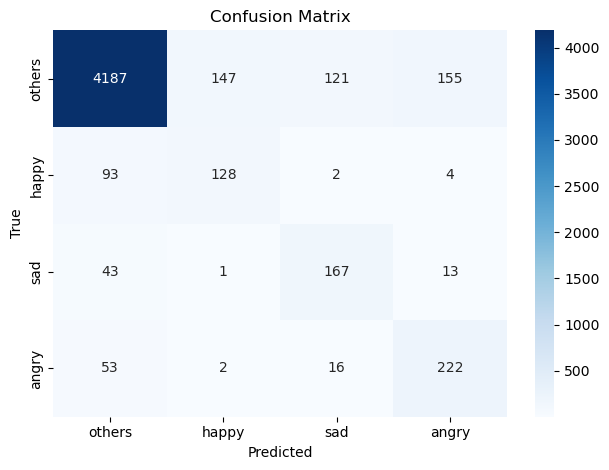

In [ ]:
# Testing The Smarter Architecture

def main():

    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    # Hyperparameters
    batch_size = 4000
    max_len = 60
    hidden_dim = 64
    sswe_dim = 50
    glove_dim = 100
    num_classes = 4
    dropout = 0.25
    learning_rate = 0.005
    epochs = 8
    device = "cuda" if torch.cuda.is_available() else "cpu"

    sswe_path = "word_embeddings/sswe_embedding.txt"
    glove_path = "word_embeddings/glove.6B.100d.txt"

    print("Loading embeddings...")
    sswe_dict = load_sswe_embeddings(sswe_path)
    glove_dict = load_glove_embeddings(glove_path)

    print("Building DataLoaders...")
    train_loader, val_loader, test_loader, word2idx, idx2word = get_dataloaders(batch_size, max_len, sswe_dict, glove_dict)

    print("Building embedding matrices...")
    sswe_matrix, glove_matrix = build_embedding_matrices(word2idx, sswe_dict, glove_dict, sswe_dim, glove_dim)

    print("Initializing SS-BED Context Model...")
    vocab_size = len(word2idx)
    model = SSBedContextModel(vocab_size, sswe_dim, glove_dim, hidden_dim, num_classes, sswe_matrix, glove_matrix, dropout)

    print("Training...")
    train__enhanced_model(model, train_loader, val_loader, epochs, learning_rate, device)

    print("Final evaluation on test set...")
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate_enhanced_model(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    evaluate_and_print_enhanced_model(model, test_loader, device)

if __name__ == "__main__":
    main()